In [ ]:
from functools import partial

import jax
from jax import numpy as jnp
import numpy as np
import einops

import equinox as eqx
from equinox.nn import Linear

from typing import Optional
from jaxtyping import Float, Array, PRNGKeyArray

import matplotlib.pyplot as plt

from jepax.data import build_dataset
from jepax.model.masker import IJEPAMasker

dataloader, _, _, _ = build_dataset("CIFAR10", data_dir="~/data")
x, y = next(iter(dataloader))

/Users/anton/source/jepax/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


## predictor cookbook

- project down to lower dim
- 2D pos embedding for unmasked tokens from context
- concatenate a special mask token embedding + pos embeddings for each token in the batch of 4 masks
- forward pass, get corresponding output token

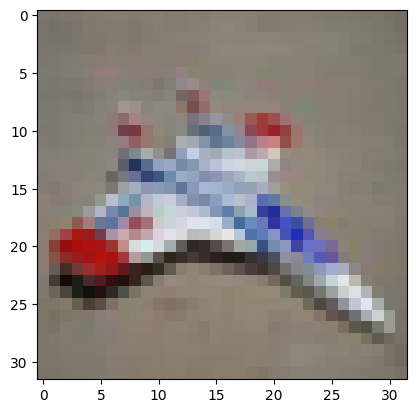

In [3]:
x_in = x[-2]
plt.imshow(x_in)

In [4]:
masker = IJEPAMasker(32, 32, 2, ctx_scale=0.8, ctx_aspect=1.0, pred_scale=0.2, pred_aspect=(0.9, 1.2))
M = 4

@partial(jax.jit, static_argnums=(1,2))
def create_mask(key, M, flatten):
    return masker(key, M, flatten=flatten)

key = jax.random.PRNGKey(11)
mask_ctx, mask_pred = create_mask(key, M, True)

print(mask_ctx.shape, mask_pred.shape)

JitTracer<float32[]>
(256,) (4, 256)


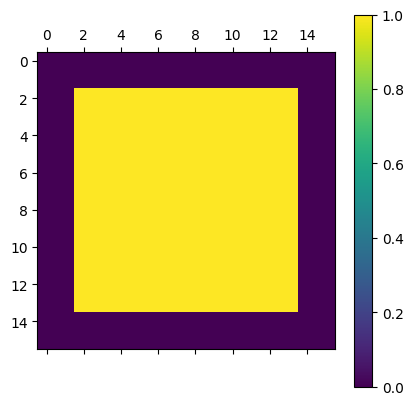

In [5]:
plt.matshow(mask_ctx.reshape(16,16))
plt.colorbar()

## Encoder

In [5]:
from jepax.model.masker import set_token_mask
from jepax.model.transformer import Transformer, PositionalEncoding
from jepax.model.vit import PatchEmbedding

class IJEPAEncoder(eqx.Module):
    embed: PatchEmbedding
    transformer: Transformer
    mask_token: Array

    def __init__(
        self,
        num_channels: int,
        patch_size: int,
        img_size: int,
        dim: int,
        num_layers: int,
        num_head: int,
        mlp_ratio: float = 3.0,
        p_drop: float = 0.1,
        seq_len: int = 2048,        
        *,
        key: PRNGKeyArray
    ):
        k1, k2, k3 = jax.random.split(key, 3)

        self.embed = PatchEmbedding(num_channels, dim, patch_size, k1)
        self.transformer = Transformer(
            dim=dim, 
            num_layers=num_layers,
            num_head=num_head,
            mlp_ratio=mlp_ratio,
            p_drop=p_drop,
            seq_len=seq_len,
            grid_size=img_size // patch_size,
            pe_type="2d",
            key=k2
        )
        self.mask_token = jax.random.normal(k3, (1, dim))


    def __call__(self, key, x, mask=None, train=True):
        x = self.embed(x)

        if mask is not None:
            x = set_token_mask(x, mask, self.mask_token)

        x = self.transformer(x, key=key, train=train)
        
        return x
    
class IJEPAPredictor(eqx.Module):
    in_proj: eqx.nn.Linear
    out_proj: eqx.nn.Linear
    transformer: Transformer
    num_mask: int = eqx.field(static=True)

    def __init__(
        self,
        latent_dim: int,
        dim: int,
        num_layers: int,
        num_head: int,
        num_mask: int,
        mlp_ratio: float = 3.0,
        p_drop: float = 0.1,
        seq_len: int = 2048,
        *,
        key: PRNGKeyArray
    ):
        k1, k2, k3, k4 = jax.random.split(key, 4)

        self.num_mask = num_mask

        self.in_proj = eqx.nn.Linear(latent_dim, dim, key=k1)
        self.transformer = Transformer(
            dim=dim, 
            num_layers=num_layers,
            num_head=num_head,
            mlp_ratio=mlp_ratio,
            p_drop=p_drop,
            seq_len=seq_len,
            key=k2
        )
        self.mask_token = jax.random.normal(k3, (1, dim))
        self.out_proj = eqx.nn.Linear(dim, latent_dim, key=k4)
        self.pe = PositionalEncoding(dim=dim, seq_len=seq_len)

    def __call__(self, key, x: Float[Array, "T D"], mask_pred: Float[Array, "Bm T D"], train=True):
        x = self.pe(x)
        num_mask = mask_pred.shape[0]
        x = jnp.repeat(x[None], num_mask, axis=0)

        x = self.transformer(x, key=key, train=train, use_pe=False)

        return x

## Encoder

In [6]:
key = jax.random.PRNGKey(0)
model = IJEPAEncoder(
    key=key,
    num_channels=3,
    patch_size=2,
    dim=12,
    num_head=3,
    num_layers=1,
    img_size=32
)

/Users/anton/source/jepax/jepax/model/transformer.py:210: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.pe = PositionalEncoding2D(


In [7]:
mask_pred.shape

(4, 256)

In [8]:
tokens = model.embed(x_in)
set_token_mask(tokens, mask_ctx, jnp.zeros((12,)))

mask_enc = ~(~mask_ctx | jnp.any(mask_pred, axis=0))

In [9]:
key, key_f = jax.random.split(key, 2)
# mask
x_m = model(key_f, x_in, mask_enc)

In [10]:
x_m.shape

(256, 12)

In [11]:
x_m

Array([[ 1.4023851 ,  0.8017022 , -0.9805692 , ..., -1.3370045 ,
        -1.0198772 ,  1.7607462 ],
       [ 1.405709  ,  0.79395014, -0.88602906, ..., -1.3891367 ,
        -1.0644593 ,  1.770953  ],
       [ 1.8269477 ,  0.80058914, -0.97521853, ..., -1.1403935 ,
        -1.193382  ,  1.1642587 ],
       ...,
       [ 1.8280985 ,  0.92669886, -1.0211883 , ..., -0.992874  ,
        -1.2108033 ,  1.1496078 ],
       [ 0.9746223 ,  0.6278084 , -0.96105075, ..., -0.9349058 ,
        -1.2606033 ,  2.012098  ],
       [ 1.4551194 ,  0.4938154 , -0.5021128 , ..., -0.9936567 ,
        -1.2628318 ,  1.9779294 ]], dtype=float32)

In [12]:
# no mask
x = model(key_f, x_in).shape

In [13]:
x_m[mask_pred[0]].shape

(6, 12)

## Predictor

In [ ]:
# mask indices for 2d pos encoding
# size
indices = jnp.where(mask_pred[0].reshape(16,16), size=16, fill_value=-1)
indices

(Array([11, 11, 12, 12, 13, 13, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],      dtype=int32),
 Array([ 0,  1,  0,  1,  0,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],      dtype=int32))

- create forward pass by concatenating prev tokens + pred mask
- add the mask, variable mask sizes for bucketing
- specify fill value: -1, add fill token
- 